#### Task 1: Load first a subset of the data to be analyzed


In [1]:
def load_csv(file_path):
    data = []
    with open(file_path, mode='r', newline='') as csvfile:
        rows = [line.strip().split(",") for line in csvfile]
    return rows

In [2]:
data = load_csv("C:\\programming stuff\\Masters_AI\\AI_programming\\lab2\\inc_subset.csv")

In [3]:
import pandas as pd
data_df = pd.DataFrame(data[1:], columns=data[0])
data_df.drop(columns=data_df.columns[0], inplace=True)
data_df.head(10)

,age,2020
0,20,129.24285714285713
1,21,146.3095238095238
2,22,164.0
3,23,182.3952380952381
4,24,202.0761904761905
5,25,224.13809523809522
6,26,242.61904761904762
7,27,258.2333333333333
8,28,271.52857142857147
9,29,282.8333333333333


In [4]:
#print vs debugger
#print statement lets you quickly output information to the console for debugging purposes
#debugger allows you to pause the execution of your code and inspect the current state of your program
#print is useful for quick checks, while a debugger is more powerful for in-depth debugging

#### Task 2: Linear regression on a data subset.

In [5]:
#so we have 2 columns for the dataset
#the first column which is the age represents the input features
#the second column which is the salary in 2020 represents the target labels
# so the linear relation is 
# salary = m * age + c
# we need to calculate the values of m and c as
# m = (N * Σ(age * salary) - Σ(age) * Σ(salary)) / (N * Σ(age^2) - (Σ(age))^2)
# c = (Σ(salary) - m * Σ(age)) / N

In [6]:
# dividing the data into training and testing sets
len(data_df)   
data_df = data_df.astype(float)

train_df = data_df.sample(frac=0.8, random_state=42)  # random 80% of rows
test_df = data_df.drop(train_df.index)                # the other 20%

X_train, y_train = train_df["age"].tolist(), train_df["2020"].tolist()
X_test,  y_test  = test_df["age"].tolist(),  test_df["2020"].tolist()

print(len(train_df), len(test_df))

# verifying the first few rows of the training and testing sets
print(train_df.head())
print(test_df.head())


24 6
     age        2020
27  47.0  414.066667
15  35.0  327.876190
23  43.0  391.447619
17  37.0  343.147619
8   28.0  271.528571
     age        2020
6   26.0  242.619048
7   27.0  258.233333
10  30.0  291.066667
14  34.0  319.252381
19  39.0  362.828571


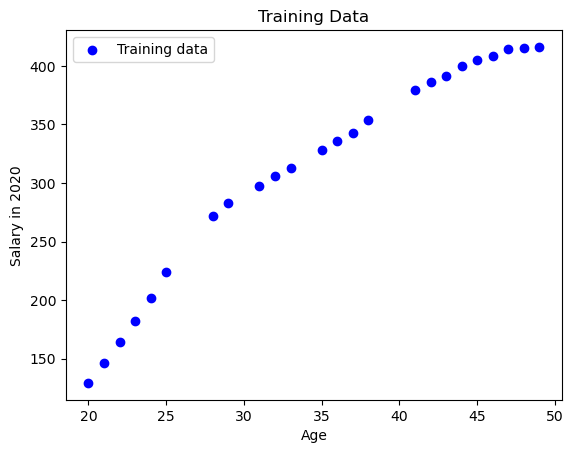

In [7]:
import matplotlib.pyplot as plt

# plotting the training data
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.xlabel('Age')
plt.ylabel('Salary in 2020')
plt.title('Training Data')
plt.legend()
plt.show()

In [8]:
def regression_cal(X, y):
    m = (len(X) * sum(x*y for x, y in zip(X, y)) - sum(X) * sum(y)) / (len(X) * sum(x**2 for x in X) - sum(X)**2)
    c = (sum(y) - m * sum(X)) / len(X)
    return m, c
def predict(X, m, c):
    return [m*x + c for x in X]

In [9]:
m,c = regression_cal(X_train, y_train)
y_train_pred = predict(X_train, m, c)
y_test_pred = predict(X_test, m, c)

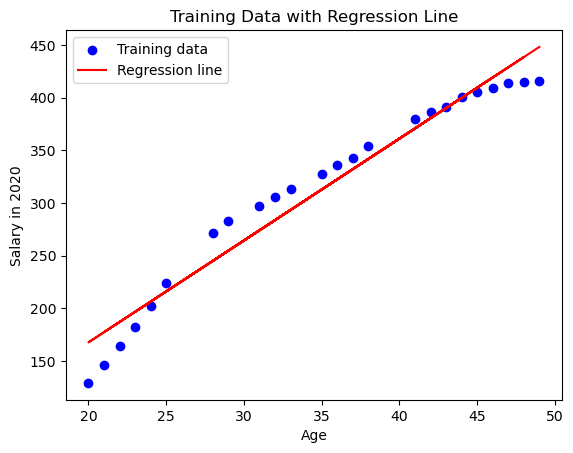

In [10]:
# plotting the regression line
plt.scatter(X_train, y_train, color='blue', label='Training data')
m,c = regression_cal(X_train, y_train)
plt.plot(X_train, y_train_pred, color='red', label='Regression line')
plt.xlabel('Age')
plt.ylabel('Salary in 2020')
plt.title('Training Data with Regression Line')
plt.legend()
plt.show()



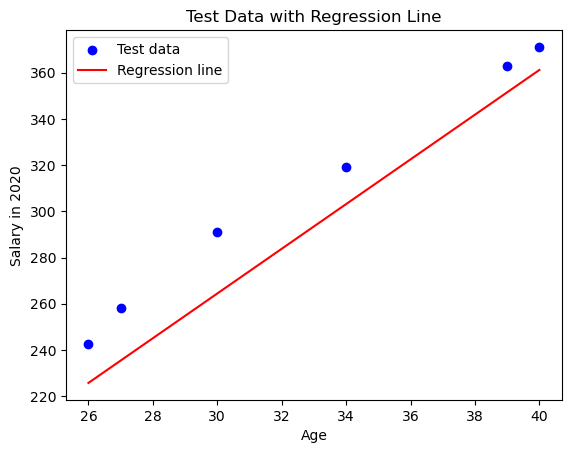

In [11]:
plt.scatter(X_test, y_test, color='blue', label='Test data')
m,c = regression_cal(X_train, y_train)
plt.plot(X_test, y_test_pred, color='red', label='Regression line')
plt.xlabel('Age')
plt.ylabel('Salary in 2020')
plt.title('Test Data with Regression Line')
plt.legend()
plt.show()

In [12]:

print("Real values vs Predicted values:")
for real, pred in zip(y_test, y_test_pred):
    print(f"Real: {real}, Predicted: {pred}")

Real values vs Predicted values:
Real: 242.61904761904762, Predicted: 225.74974238844058
Real: 258.2333333333333, Predicted: 235.41942784496902
Real: 291.06666666666666, Predicted: 264.4284842145544
Real: 319.252380952381, Predicted: 303.10722604066814
Real: 362.8285714285714, Predicted: 351.4556533233104
Real: 371.0952380952381, Predicted: 361.12533877983884


In [13]:
def mse_cal(y_real, y_pred):
    # compare each real value with its predicted value, square the error, then average
    squared_errors = []
    for real, pred in zip(y_real, y_pred):
        error = real - pred
        squared_errors.append(error**2)
    return sum(squared_errors) / len(squared_errors)
print("MSE on Training Data:", mse_cal(y_train, y_train_pred))
print("MSE on Test Data:", mse_cal(y_test, y_test_pred))

MSE on Training Data: 369.32127700855455
MSE on Test Data: 334.00811544313393


#### the error is pretty much same on the datasets, the test MSE is little lower than train, it means the model is not overfitting, and it preidcts pretty decent on the values it hasnt seen, we clearly see a non linear relationship of age and salary so according to the dataset linear regression is a good choice but there is definitely some offset for the predicted values however a curve might fit the data better

### Task 3: Linear regression on full dataset

In [14]:
full_data = load_csv("C:\\programming stuff\\Masters_AI\\AI_programming\\lab2\\inc_utf.csv")
full_data_df = pd.DataFrame(full_data[1:], columns=full_data[0])
full_data_df.drop(columns=full_data_df.columns[0], inplace=True)
full_data_df.head(10)

,region,age,2020
0,01 Stockholm county,16 years,4.6
1,01 Stockholm county,17 years,8.8
2,01 Stockholm county,18 years,17.8
3,01 Stockholm county,19 years,52.5
4,01 Stockholm county,20 years,112.0
5,01 Stockholm county,21 years,127.9
6,01 Stockholm county,22 years,147.1
7,01 Stockholm county,23 years,167.9
8,01 Stockholm county,24 years,191.8
9,01 Stockholm county,25 years,225.2


In [15]:
type(full_data_df['2020'].iloc[0]),type(full_data_df['age'].iloc[0])

(str, str)

In [16]:
full_data_clean = full_data_df[['region', 'age', '2020']].copy()
full_data_clean['age'] = full_data_clean['age'].str.replace(' years', '').str.replace('+', '').astype(int)
full_data_clean['2020'] = full_data_clean['2020'].astype(float)

type(full_data_clean['2020'].iloc[0]),type(full_data_clean['age'].iloc[0])

(numpy.float64, numpy.int32)

In [17]:
full_data_clean.head(100)

,region,age,2020
0,01 Stockholm county,16,4.6
1,01 Stockholm county,17,8.8
2,01 Stockholm county,18,17.8
3,01 Stockholm county,19,52.5
4,01 Stockholm county,20,112.0
...,...,...,...
95,03 Uppsala county,26,219.1
96,03 Uppsala county,27,247.0
97,03 Uppsala county,28,268.0
98,03 Uppsala county,29,282.6


In [18]:
#group by age and calculate the average salary in 2020 in all regions
grouped_data_df = full_data_clean.groupby('age')['2020'].mean().reset_index()
grouped_data_df.head()

,age,2020
0,16,5.471429
1,17,10.552381
2,18,22.390476
3,19,65.376190
4,20,129.242857


In [19]:
len(grouped_data_df) #which means the number of unique age groups in the dataset

85

In [20]:
train_grp_df = grouped_data_df.sample(frac=0.8, random_state=42)
test_grp_df = grouped_data_df.drop(train_grp_df.index)

x_train_grp,y_train_grp = train_grp_df[['age']].values, train_grp_df['2020'].values
x_test_grp,y_test_grp = test_grp_df[['age']].values, test_grp_df['2020'].values

print(len(x_train_grp), len(x_test_grp))

68 17


In [21]:
m,c = regression_cal(x_train_grp, y_train_grp)
y_train_grp_pred = predict(x_train_grp, m, c)
y_test_grp_pred = predict(x_test_grp, m, c)

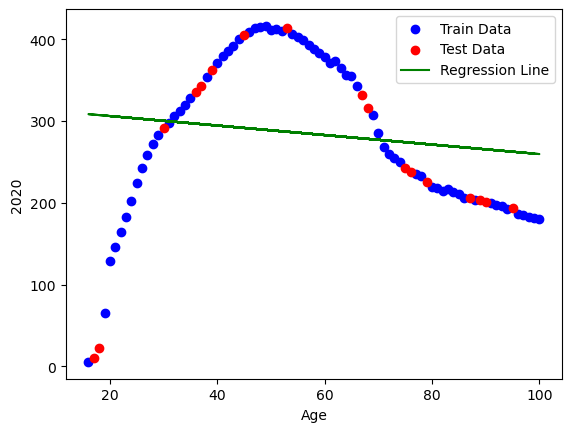

In [22]:
plt.scatter(x_train_grp, y_train_grp, color='blue', label='Train Data')
plt.scatter(x_test_grp, y_test_grp, color='red', label='Test Data')
plt.plot(x_train_grp, y_train_grp_pred, color='green', label='Regression Line')
plt.xlabel('Age')
plt.ylabel('2020')
plt.legend()
plt.show()

In [34]:
x_train_grp.shape

(68, 1)

In [35]:
y_train_grp.shape

(68,)

In [23]:

print("Real values vs Predicted values:")
for real, pred in zip(y_test_grp, y_test_grp_pred):
    print(f"Real: {real}, Predicted: {pred}")

Real values vs Predicted values:
Real: 10.552380952380952, Predicted: [307.81141497]
Real: 22.39047619047619, Predicted: [307.23031833]
Real: 291.06666666666666, Predicted: [300.25715866]
Real: 335.7238095238095, Predicted: [296.77057883]
Real: 343.14761904761906, Predicted: [296.18948219]
Real: 362.8285714285714, Predicted: [295.02728891]
Real: 405.5, Predicted: [291.54070908]
Real: 413.4619047619048, Predicted: [286.89193597]
Real: 332.1666666666667, Predicted: [278.75658302]
Real: 316.34285714285716, Predicted: [278.17548638]
Real: 242.47619047619048, Predicted: [274.10780991]
Real: 237.3904761904762, Predicted: [273.52671327]
Real: 225.3095238095238, Predicted: [271.78342336]
Real: 205.39999999999998, Predicted: [267.13465025]
Real: 203.94285714285715, Predicted: [265.97245697]
Real: 200.82380952380953, Predicted: [265.39136033]
Real: 194.1, Predicted: [262.48587713]


In [24]:
print("MSE on Training Data:", mse_cal(y_train_grp, y_train_grp_pred))
print("MSE on Test Data:", mse_cal(y_test_grp, y_test_grp_pred))

MSE on Training Data: [9115.92232704]
MSE on Test Data: [13658.07508583]


In [25]:
## the mean squared error is too high in this task, as the linear regression model may not be capturing the 
# underlying complexity of the data as we can see from the scatter plot. 

#### Task 4: Reflections.

In [41]:
## based on the scatter plots, in the first dataset, linear regression predicted the values reasonably well,
#  while in the second dataset, linear regression was not sufficient, and a polynomial regression model would be
#  more suitable due to the non-linear relationship between the variables.

#### Task 5: Polynomial regression with hyperparameter tunning

In [28]:
import sklearn
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degrees = [2, 3, 5, 8]
results = {}

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    x_train_poly = poly.fit_transform(x_train_grp)
    x_test_poly = poly.transform(x_test_grp)

    model = LinearRegression().fit(x_train_poly, y_train_grp)

    train_mse = mse_cal(y_train_grp, model.predict(x_train_poly))
    test_mse = mse_cal(y_test_grp, model.predict(x_test_poly))
    results[d] = (poly, model)
    print(f"degree {d}: train MSE = {train_mse:.1f}, test MSE = {test_mse:.1f}")


degree 2: train MSE = 2225.6, test MSE = 3644.0
degree 3: train MSE = 188.8, test MSE = 333.5
degree 5: train MSE = 151.9, test MSE = 405.5
degree 8: train MSE = 41.6, test MSE = 139.8


In [36]:
print(model.coef_)
print(model.intercept_)

[ 0.00000000e+00  5.42020433e+01 -8.57773995e-01  4.01026261e-03]
-664.4503639150241


In [ ]:
poly, model = results[3]

x_test_poly_3 = poly.transform(x_test_grp)

### when the degree is 3 the model is reasonably close to the actual values, as the degree grows the model will overfit and thats now what we want, so we go ahead with 3 degree polynomial function

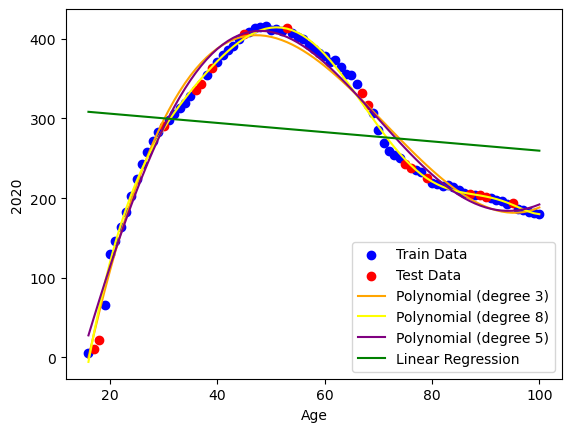

In [49]:
best_d = 3   # set this to the degree with the lowest TEST MSE from the loop
poly, model = results[best_d]
poly_8, model_8 = results[8]
poly_5, model_5 = results[5]
import numpy as np
ages = np.arange(16, 101).reshape(-1, 1)
plt.scatter(x_train_grp, y_train_grp, color='blue', label='Train Data')
plt.scatter(x_test_grp, y_test_grp, color='red', label='Test Data')
plt.plot(ages, model.predict(poly.transform(ages)), color='orange', label=f'Polynomial (degree {best_d})')
plt.plot(ages, model_8.predict(poly_8.transform(ages)), color='yellow', label=f'Polynomial (degree {8})')
plt.plot(ages, model_5.predict(poly_5.transform(ages)), color='purple', label=f'Polynomial (degree {5})')
plt.plot(ages, m*ages + c, color='green', label='Linear Regression')
plt.xlabel('Age')
plt.ylabel('2020')
plt.legend()
plt.show()